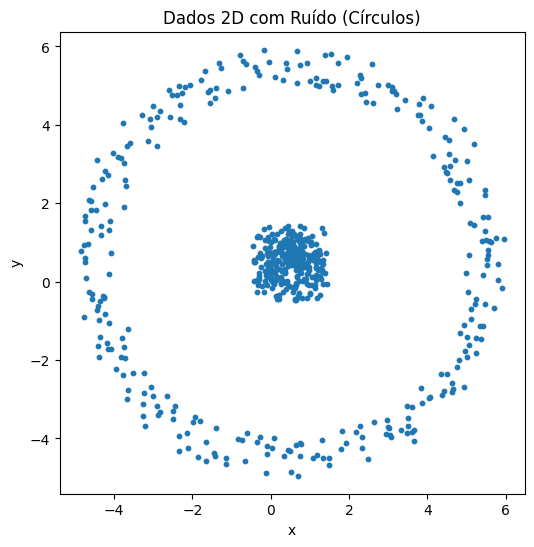

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
N = 300  # Tamanho de cada cluster
r1 = 0.5  # Raio do primeiro círculo
r2 = 5    # Raio do segundo círculo
theta = np.linspace(0, 2 * np.pi, N)  # Valores de theta

# Gerando os pontos para o primeiro círculo (com ruído)
X1 = r1 * np.column_stack((np.cos(theta), np.sin(theta))) + np.random.rand(N, 2)

# Gerando os pontos para o segundo círculo (com ruído)
X2 = r2 * np.column_stack((np.cos(theta), np.sin(theta))) + np.random.rand(N, 2)

# Unindo os dois conjuntos de pontos
X = np.vstack((X1, X2))

# Plotando os dados
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=10)
plt.title("Dados 2D com Ruído (Círculos)")
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.show()


In [ ]:
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

iris = datasets.load_iris()
X_iris = iris.data
y_true = iris.target

scaler = StandardScaler()
X_iris_std = scaler.fit_transform(X_iris)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_iris_std)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


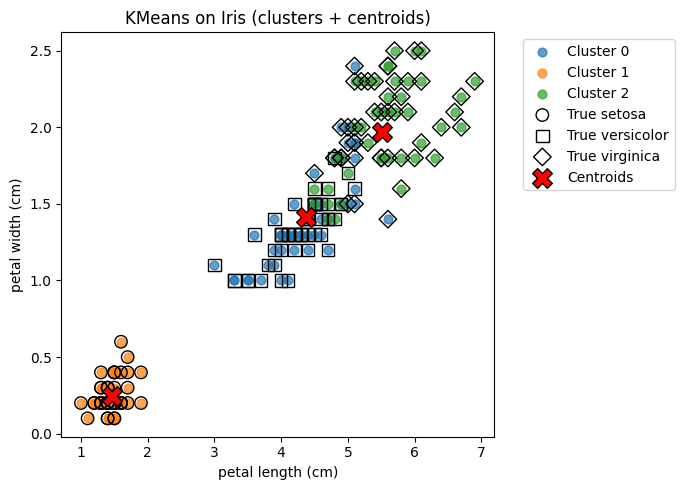

In [12]:
# Choose petal length and width for plotting (features 2 and 3)
labels_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_
feat_x, feat_y = 2, 3
X_plot = X_iris[:, [feat_x, feat_y]]
centroids_orig = scaler.inverse_transform(centroids)[:, [feat_x, feat_y]]

plt.figure(figsize=(7,5))
for k in range(3):
    pts = X_plot[labels_kmeans == k]
    plt.scatter(pts[:,0], pts[:,1], s=40, label=f'Cluster {k}', alpha=0.7)
markers = ['o', 's', 'D']
for cls in np.unique(y_true):
    pts = X_plot[y_true == cls]
    plt.scatter(pts[:,0], pts[:,1], facecolors='none', edgecolors='k', marker=markers[cls], s=80, label=f'True {iris.target_names[cls]}')
plt.scatter(centroids_orig[:,0], centroids_orig[:,1], marker='X', s=200, c='red', label='Centroids', edgecolors='k')
plt.xlabel(iris.feature_names[feat_x]); plt.ylabel(iris.feature_names[feat_y])
plt.title('KMeans on Iris (clusters + centroids)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
# DBSCAN example with make_moons
X_moons, y_moons_true = make_moons(n_samples=400, noise=0.08, random_state=42)
scaler2 = StandardScaler()
X_moons_std = scaler2.fit_transform(X_moons)
db = DBSCAN(eps=0.25, min_samples=5, metric='euclidean', n_jobs=-1)
db.fit(X_moons_std)

,eps,0.25
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,-1


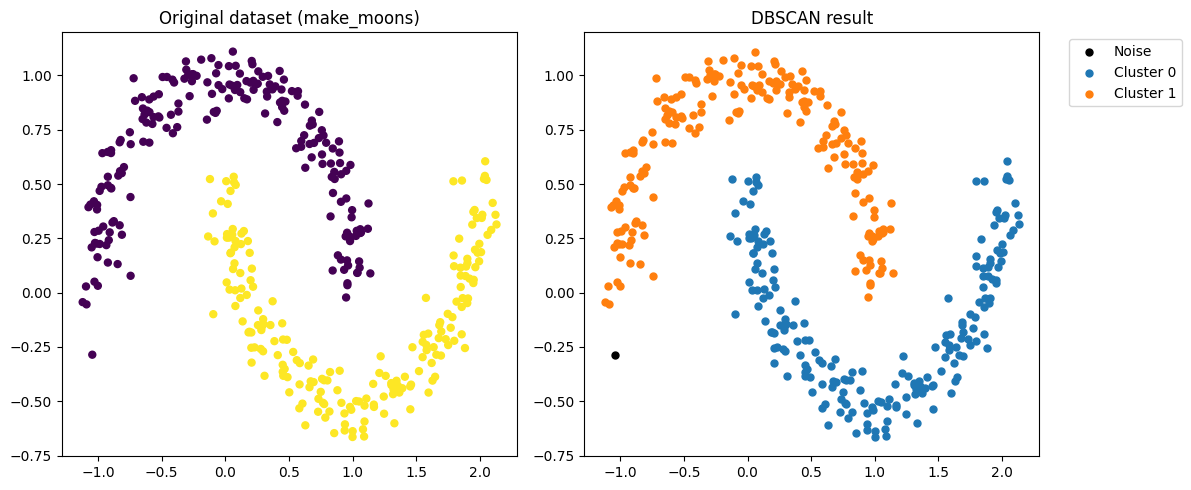

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons_true, cmap='viridis', s=25)
plt.title('Original dataset (make_moons)')
plt.subplot(1,2,2)


labels_db = db.labels_
unique_labels = np.unique(labels_db)
for lab in unique_labels:
    pts = X_moons[labels_db == lab]
    if lab == -1:
        plt.scatter(pts[:,0], pts[:,1], c='k', s=25, label='Noise')
    else:
        plt.scatter(pts[:,0], pts[:,1], s=25, label=f'Cluster {lab}')
plt.title('DBSCAN result')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


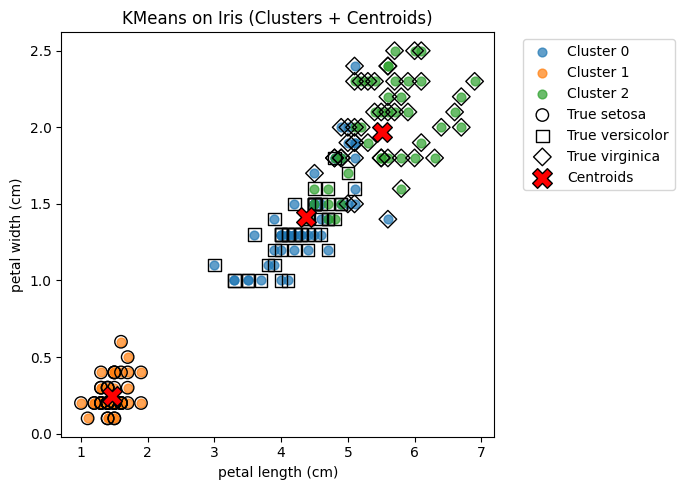

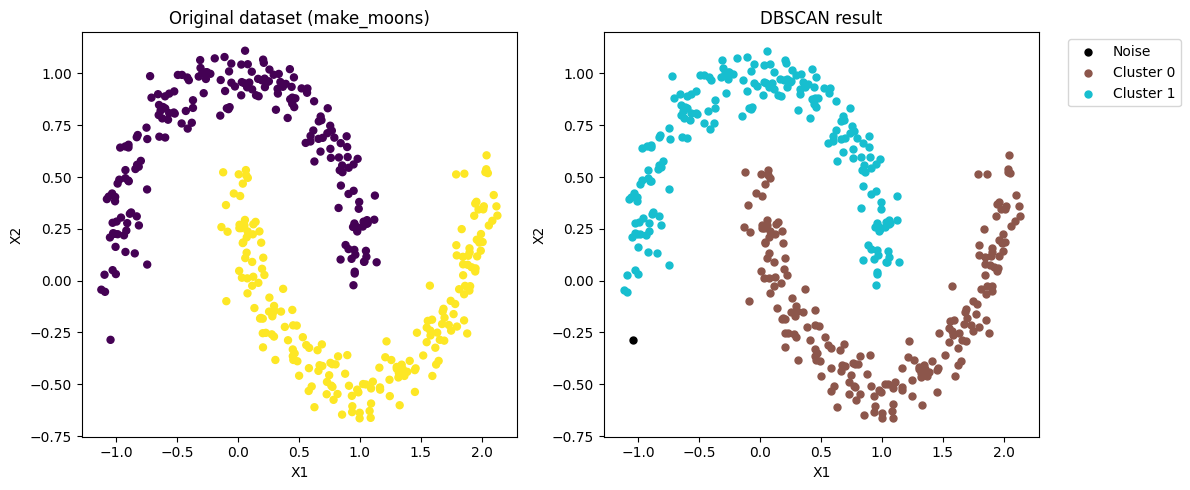

In [14]:
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# PARTE 1: KMeans no Iris
# -----------------------------
iris = datasets.load_iris()
X_iris = iris.data
y_true = iris.target

# Padronizando os dados
scaler = StandardScaler()
X_iris_std = scaler.fit_transform(X_iris)

# Aplicando KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_iris_std)
labels_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_

# Escolhendo features para plot (petal length e width)
feat_x, feat_y = 2, 3
X_plot = X_iris[:, [feat_x, feat_y]]
centroids_orig = scaler.inverse_transform(centroids)[:, [feat_x, feat_y]]

plt.figure(figsize=(7,5))
# Plot clusters KMeans
for k in range(3):
    pts = X_plot[labels_kmeans == k]
    plt.scatter(pts[:,0], pts[:,1], s=40, alpha=0.7, label=f'Cluster {k}')
# Plot classes verdadeiras
markers = ['o', 's', 'D']
for cls in np.unique(y_true):
    pts = X_plot[y_true == cls]
    plt.scatter(pts[:,0], pts[:,1], facecolors='none', edgecolors='k', marker=markers[cls], s=80,
                label=f'True {iris.target_names[cls]}')
# Centróides
plt.scatter(centroids_orig[:,0], centroids_orig[:,1], marker='X', s=200, c='red', edgecolors='k', label='Centroids')
plt.xlabel(iris.feature_names[feat_x])
plt.ylabel(iris.feature_names[feat_y])
plt.title('KMeans on Iris (Clusters + Centroids)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig("kmeans_iris.pdf")
plt.show()

# -----------------------------
# PARTE 2: DBSCAN com make_moons
# -----------------------------
X_moons, y_moons_true = make_moons(n_samples=400, noise=0.08, random_state=42)

# Padronizando
scaler2 = StandardScaler()
X_moons_std = scaler2.fit_transform(X_moons)

# Aplicando DBSCAN
db = DBSCAN(eps=0.25, min_samples=5, metric='euclidean', n_jobs=-1)
db.fit(X_moons_std)
labels_db = db.labels_
unique_labels = np.unique(labels_db)

# Plot original e clusters DBSCAN
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons_true, cmap='viridis', s=25)
plt.title('Original dataset (make_moons)')
plt.xlabel('X1')
plt.ylabel('X2')

# DBSCAN
plt.subplot(1,2,2)
colors = plt.cm.tab10(np.linspace(0,1,len(unique_labels)))
for lab, col in zip(unique_labels, colors):
    pts = X_moons[labels_db == lab]
    if lab == -1:
        plt.scatter(pts[:,0], pts[:,1], c='k', s=25, label='Noise')
    else:
        plt.scatter(pts[:,0], pts[:,1], s=25, color=col, label=f'Cluster {lab}')
plt.title('DBSCAN result')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.savefig("dbscan_moons.pdf")
plt.show()
